In [2]:
import yaml
import wandb
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
from main.sampler.sampler import ParallelTempering
from main.sampler.dyn_mcmc_warp import DynSamplerWrapper
from main.targets.aldp import AldpPotential
from main.targets.aldp_cartesian import AldpPotentialCart
from main.targets.gmm import GMM

Warning on use of the timeseries module: If the inherent timescales of the system are long compared to those being analyzed, this statistical inefficiency may be an underestimate.  The estimate presumes the use of many statistically independent samples.  Tests should be performed to assess whether this condition is satisfied.   Be cautious in the interpretation of the data.

****** PyMBAR will use 64-bit JAX! *******
* JAX is currently set to 32-bit bitsize *
* which is its default.                  *
*                                        *
* PyMBAR requires 64-bit mode and WILL   *
* enable JAX's 64-bit mode when called.  *
*                                        *
* This MAY cause problems with other     *
* Uses of JAX in the same code.          *
******************************************



# Introduction
In this notebook, you could simulate samples with shape (num_temperature, num_chains, num_steps, dim) using **Parallel Tempering**.

For test, you can simulate a 40-mode Mixture of Gaussian in 2-dimensional space.

For Alanine Dipeptide (ALDP), You can either simulate either in: 
    1. internal coordinate, *i.e.* torsional angles etc, using AldpPotential; or 
    2. Cartesian coordinate, *i.e.* the 3D coordinate of each atom, using AldpPotentialCart


In [ ]:
"""
Download the data first
"""
os.makedirs("data/", exist_ok=True)
os.makedirs("data/aldp/", exist_ok=True)

In [ ]:
!wget -O data/aldp/train.pt "https://zenodo.org/records/6993124/files/train.pt?download=1"

--2025-03-28 23:00:01--  https://zenodo.org/records/6993124/files/train.pt?download=1
Resolving zenodo.org (zenodo.org)... 188.185.45.92, 188.185.43.25, 188.185.48.194, ...
Connecting to zenodo.org (zenodo.org)|188.185.45.92|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 480000747 (458M) [application/octet-stream]
Saving to: ‘data/aldp/train.pt’

data/aldp/train.pt   83%[===============>    ] 379.96M   113MB/s    eta 1s     ^C


## Set up your config
You need to set:
1. target distribution: "gmm"/"aldp_inter"/"aldp_cart"
2. temperature: 
    - schedule: "geom"/"linear"
    - max temperature
    - min temperature
    - num. of temperature
3. how many chains you want to run parallely. 
 - FYI: the "chain" here is totally different from "num. of temperature", it refers to how many copies of PT you want to run simultainously
4. (optional) Your wandb account, for logging metrics like swap rate. Please set your wandb in "configs/logger/wandb.yaml"

For simplicity, I didn't use yaml files in this toy notebook. But you could find different config in configs/pt

In [ ]:
torch.manual_seed(0)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
config = {
    "name": "aldp_inter",  # gmm or aldp_inter or aldp_cart
    "temp_schedule": "geom",  # geom/linear, we usually use the geometrical schedule, but you could play
    "temp_low": 1.0,
    "temp_high": 100.,
    "total_n_temp": 10,
    "num_chains": 1,
    "num_steps": 100000, # number of steps for PT simulation
    "step_size": 0.0001, # step size of MCMC
    "swap_interval": 100, # how often to swap samples between different temperatures
    "check_interval": 10000,  # how many steps to evaluate the samples
    "plot_fold": "plots",  # set where you save the plots
    "save_fold": "results",  # set where you save the results
    "use_wandb": False,
    "device": device
}

## Set up

In [38]:
"""
Set up WandB
"""
if config["use_wandb"]:
    with open('configs/wandb.yaml', 'r') as file:
        wandb_config = yaml.safe_load(file)

    wandb_config['tags'] = ['PT', config["name"]]
    wandb_config['group'] = config["name"]
    wandb.init(
        entity=wandb_config['entity'],
        project=wandb_config['project'],
        mode="online" if not wandb_config['offline'] else "offline",
        group=wandb_config['group'],
        tags=wandb_config['tags'],
        config=config
    )

In [39]:
"""
Set up temperatures
"""

'\nSet up temperatures\n'

In [40]:
if config["temp_schedule"] == 'geom':
    all_temps = torch.from_numpy(np.geomspace(config["temp_low"], config["temp_high"], config["total_n_temp"])).float().to(config["device"])
elif config["temp_schedule"] == 'linear':
    all_temps = torch.linspace(config["temp_low"], config["temp_high"], config["total_n_temp"]).float().to(config["device"])

In [ ]:
"""
Set up target distribution
"""
if config["name"] == "gmm":
    dim = 2
    target = GMM(dim=dim, n_mixes=40, loc_scaling=40., log_var_scaling=1.0, seed=0, n_test_set_samples=1000, device=config["device"])

elif config["name"] == "aldp_inter":
    from main.targets.aldp import get_aldp_potential
    dim = 60
    aldp_config_path = "configs/aldp/aldp_config.yaml"
    target = get_aldp_potential(aldp_config_path, device=config["device"])

elif config["name"] == "aldp_cart":
    from main.targets.aldp_cartesian import get_aldp_potential
    dim = 66
    aldp_config_path = "configs/aldp/aldp_config.yaml"
    target = get_aldp_potential(aldp_config_path, device=config["device"])
else:
    raise ValueError("Unknown target")

Process ForkPoolWorker-92:
Process ForkPoolWorker-77:
Process ForkPoolWorker-121:
Process ForkPoolWorker-107:
Process ForkPoolWorker-122:
Process ForkPoolWorker-106:
Process ForkPoolWorker-97:
Process ForkPoolWorker-115:
Process ForkPoolWorker-123:
Process ForkPoolWorker-116:
Process ForkPoolWorker-117:
Process ForkPoolWorker-101:
Process ForkPoolWorker-100:
Process ForkPoolWorker-119:
Process ForkPoolWorker-124:
Process ForkPoolWorker-91:
Process ForkPoolWorker-113:
Process ForkPoolWorker-118:
Process ForkPoolWorker-126:
Process ForkPoolWorker-82:
Process ForkPoolWorker-87:
Process ForkPoolWorker-104:
Process ForkPoolWorker-84:
Process ForkPoolWorker-103:
Process ForkPoolWorker-98:
Process ForkPoolWorker-93:
Process ForkPoolWorker-110:
Process ForkPoolWorker-86:
Process ForkPoolWorker-90:
Process ForkPoolWorker-70:
Process ForkPoolWorker-96:
Process ForkPoolWorker-68:
Process ForkPoolWorker-79:
Process ForkPoolWorker-83:
Process ForkPoolWorker-102:
Process ForkPoolWorker-128:
Process 

In [42]:
"""
Set up plot-saving path
"""
plot_path = f"{config['plot_fold']}/{config['name']}"
os.makedirs(config["plot_fold"], exist_ok=True)
os.makedirs(plot_path, exist_ok=True)

# PT Simulation

## 1. Choose the initial location to start running PT

In [43]:
if config["name"] == "aldp":
    init_position_file = yaml.safe_load(open(aldp_config_path, "r")).get("data", {}).get("transform")
    x_init = torch.load(init_position_file, map_location=config["device"])
    x_init = target.coordinate_transform.inverse(x_init)[0]
    x_init = x_init.unsqueeze(0).repeat(config["total_n_temp"], config["num_chains"], 1)
elif config["name"] == "aldp_cart":
    init_position_file = yaml.safe_load(open(aldp_config_path, "r")).get("data", {}).get("transform")
    x_init = torch.load(init_position_file, map_location=config["device"])
    x_init = x_init.unsqueeze(0).repeat(config["total_n_temp"], config["num_chains"], 1)
else:
    x_init = torch.randn((config["total_n_temp"], config["num_chains"], dim), device=config["device"])*0.01

## 2. Create the PT sampler object
The PT sampler object is then wrapped by the *DynSamplerWrapper*, which allows us to dynamically adjust the step size of MCMC at each temperature. The default setting is to make sure the acceptance rate of MH remains around 60%, and the hyperparameter *alpha* controls the strength of adjusting.

In [ ]:
pt = ParallelTempering(x=x_init,
                       energy_func=lambda x: -target.log_prob(x),
                       step_size=torch.tensor([config["step_size"]] * (config["total_n_temp"] * config["num_chains"]), device=config["device"]).unsqueeze(-1),
                       swap_interval=config["swap_interval"],
                       temperatures=all_temps,
                       mh=True,
                       device=config["device"])
pt = DynSamplerWrapper(pt, per_temp=True, total_n_temp=config["total_n_temp"], target_acceptance_rate=0.6, alpha=0.25)
progress_bar = tqdm(range(config["num_steps"]), desc="Parallel Tempering")
swap_rates = []
traj = []
for i in progress_bar:
    """
    The following two lines are almost all you need for sampling from PT
    """
    new_samples, acc, *_ = pt.sample()
    traj.append(new_samples.clone().detach().cpu().float())

    """
    The following codes are logging useful information
    """
    if pt.sampler.swap_rates:
        swap_rates.append(pt.sampler.swap_rates)
        if wandb.run is not None:
            for j in range(len(all_temps) - 1):
                wandb.log({f"swap_rates/{all_temps[j].item():.2f}~{all_temps[j + 1].item():.2f}": pt.sampler.swap_rates[j]}, step=i)
    if (i + 1) % config["check_interval"] == 0:
        os.makedirs(config["save_fold"], exist_ok=True)
        torch.save(torch.stack(traj, dim=2)[0].detach().cpu().float(), f"{config['save_fold']}/pt_{config['name']}.pt")
        if isinstance(target, AldpPotential) or isinstance(target, AldpPotentialCart):
            sub_plot_path = f"{plot_path}/{i + 1}"
            os.makedirs(sub_plot_path, exist_ok=True)
            images_dict = target.plot_samples(torch.stack(traj[-config["check_interval"]:], dim=2)[0].reshape(-1, dim).to(config["device"]), target.sample(1000000), i, sub_plot_path, sub_plot_path, 1000000)
            if wandb.run is not None:
                for key, value in images_dict.items():
                    wandb.log({f"{key}": wandb.Image(value)}, step=i)
        else:
            plt.figure(figsize=(6, 6))
            target.plot_samples(samples_list=[torch.stack(traj[-config["check_interval"]:], dim=2)[0].reshape(-1, dim),
                                            target.sample([config["check_interval"]])],
                                labels_list=["pt", "gt"],
                                alpha=0.5,)
            plt.legend()
            if wandb.run is not None:
                wandb.log({"samples": wandb.Image(plt)}, step=i)
            plt.close()
    if wandb.run is not None:
        for j in range(len(all_temps)):
            wandb.log({f"acc_rates/{all_temps[j].item():.2f}": acc[j].item()}, step=i)
    progress_bar.set_postfix_str(f"acc rate: {acc.mean().item()}")
traj = torch.stack(traj, dim=2)
os.makedirs(config["save_fold"], exist_ok=True)
torch.save(traj.detach().cpu().float(), f"{config['save_fold']}/pt_{config['name']}.pt")

Parallel Tempering:   0%|          | 0/1000 [00:00<?, ?it/s]/rds/user/ro352/hpc-work/accelerate-md/main/sampler/sampler.py:86: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_p = x_c - self.step_size * grad_xc + torch.sqrt(torch.tensor(2.0*self.step_size, device=self.device)) * torch.randn_like(self.x, device=self.device)
Parallel Tempering: 100%|██████████| 1000/1000 [00:33<00:00, 29.49it/s, acc rate: 0.7070593327050331]


## Example evaluation for GMM
Run the following codes for visualization of samples from PT if you are sampling from Mixture of Gaussian

In [11]:
traj.shape

torch.Size([10, 1, 10000, 2])

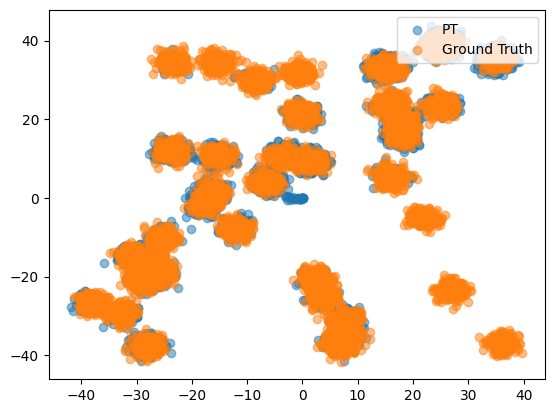

In [25]:
true_samples = target.sample((10000,))
pt_samples = traj[0, 0, :, :]
plt.figure()
plt.scatter(pt_samples[:, 0].detach().cpu().numpy(), pt_samples[:, 1].detach().cpu().numpy(), alpha=0.5, label="PT")
plt.scatter(true_samples[:, 0].detach().cpu().numpy(), true_samples[:, 1].detach().cpu().numpy(), alpha=0.5, label="Ground Truth")
plt.legend(loc="upper right")
plt.show()